In [5]:
# Library (fetches real stock data fron Yahoo Finance)
!pip install yfinance
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
# Downloading Stock Data
df = yf.download('TSLA', start='2024-03-01', end='2026-03-01' )
df.info()
df.head()
print ('Shapes:',df.shape)

/tmp/ipykernel_577/4292565513.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('TSLA', start='2024-03-01', end='2026-03-01' )
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 500 entries, 2024-03-01 to 2026-02-27
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   500 non-null    float64
 1   (High, TSLA)    500 non-null    float64
 2   (Low, TSLA)     500 non-null    float64
 3   (Open, TSLA)    500 non-null    float64
 4   (Volume, TSLA)  500 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.4 KB
Shapes: (500, 5)


In [ ]:
# Checking missing values
df.isnull().sum()

,,0
Price,Ticker,
Close,TSLA,0
High,TSLA,0
Low,TSLA,0
Open,TSLA,0
Volume,TSLA,0


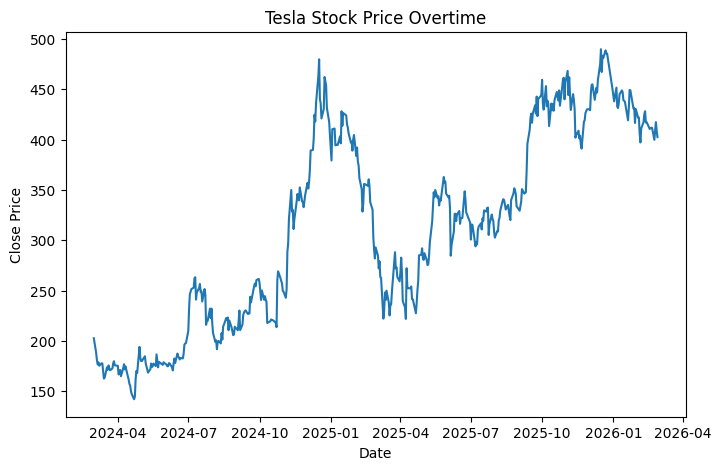

In [ ]:
# Drawing line chart
plt.figure(figsize=(8,5))
plt.plot(df.index, df[('Close', 'TSLA')])
plt.title('Tesla Stock Price Overtime')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

In [7]:
# Stats of data
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,311.099280,317.790720,304.218960,311.171300,9.271626e+07
std,96.858803,98.564962,95.157455,97.155977,3.473903e+07
min,142.050003,144.440002,138.800003,140.559998,3.625290e+07
25%,224.799999,231.412498,218.912495,224.832504,6.809338e+07
50%,318.020004,324.395004,311.085007,318.220001,8.458010e+07
75%,408.664993,417.394997,399.512497,409.750008,1.076195e+08
max,489.880005,498.829987,485.329987,489.880005,2.874998e+08


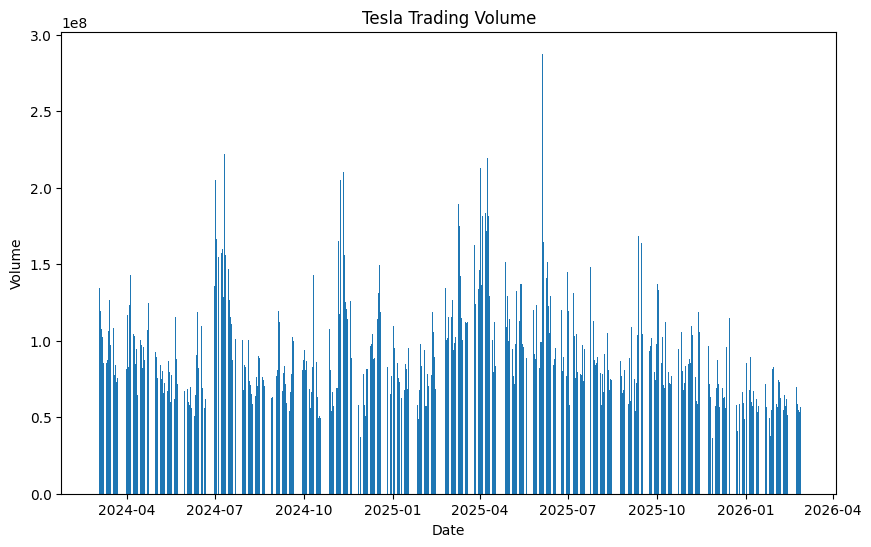

In [17]:
# Visualisation
plt.figure(figsize=(10,6))
plt.bar(df.index, df[('Volume', 'TSLA')])
plt.title('Tesla Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

In [14]:
# Calculating Moving averages
# MA50  = average of last 50 days  → short term trend
# MA200 = average of last 200 days → long term trend
df[('MA50', 'TSLA')] = df[('Close', 'TSLA')].rolling(50).mean()
df[('MA200', 'TSLA')] =  df[('Close', 'TSLA')].rolling(200).mean()

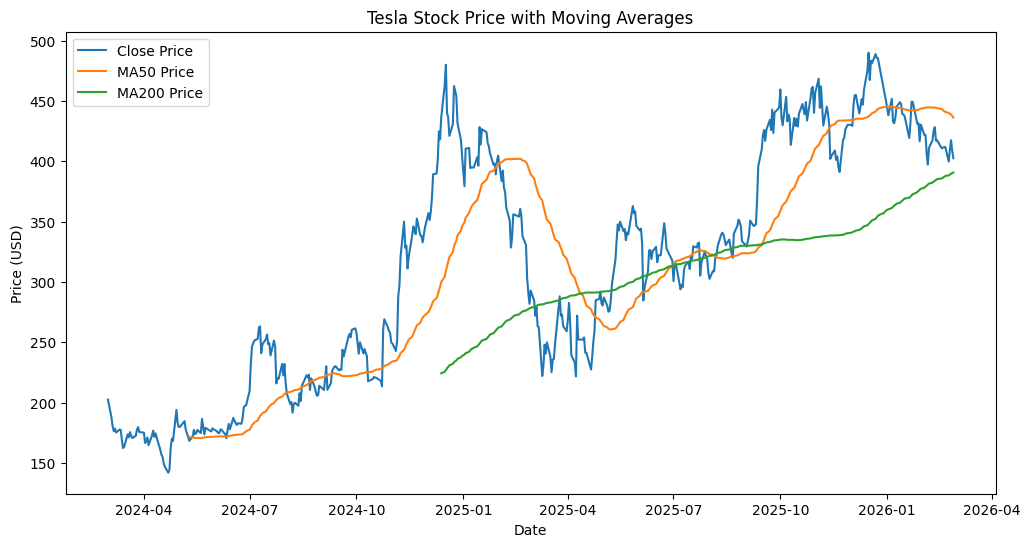

In [16]:
# Final comparison chart
plt.figure(figsize=(12,6))
plt.plot(df.index, df[('Close', 'TSLA')], label = 'Close Price')
plt.plot(df.index, df[('MA50', 'TSLA')], label='MA50 Price')
plt.plot(df.index, df[('MA200', 'TSLA')], label='MA200 Price')
plt.title('Tesla Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()